In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt

datos = pd.read_csv('data.csv')

print("Datos cargados correctamente:")
print(datos.head())

Datos cargados correctamente:
   Timestamp  speed_kmph   accel_x   accel_y  brake_pressure  steering_angle  \
0       0.00   36.075011  0.535763  0.708633       23.107812       -3.169956   
1       0.01   38.090536  0.973764  0.044312       36.961137      -24.380082   
2       0.02   71.314445  1.000000  0.789375       79.734087       -6.100238   
3       0.03   86.485997  1.000000  0.221966       45.007002       17.886191   
4       0.04   52.816777 -0.201763  0.560619       38.759612       -4.104323   

    throttle  lane_deviation  phone_usage  headway_distance  reaction_time  \
0  53.123505        0.851871            1         17.996005       1.400050   
1  36.383904        1.459495            1         29.904182       1.428537   
2  78.110507        0.254723            0         11.126012       0.406950   
3  82.794935        0.911664            0         11.064505       0.539964   
4  61.432375        1.591244            1         21.967570       1.369908   

  behavior_label  
0

In [ ]:
frecuencia = 100.0
corte = 5.0

b, a = butter(4, corte / (frecuencia / 2.0), btype='low')

datos['accel_x_limpia'] = filtfilt(b, a, datos['accel_x'])
datos['accel_y_limpia'] = filtfilt(b, a, datos['accel_y'])

datos['G_cruda'] = np.sqrt(datos['accel_x']**2 + datos['accel_y']**2)
datos['G_limpia'] = np.sqrt(datos['accel_x_limpia']**2 + datos['accel_y_limpia']**2)

print("Fuerza G máxima ruidosa:", datos['G_cruda'].max())
print("Fuerza G máxima real (filtrada):", datos['G_limpia'].max())

Fuerza G máxima ruidosa: 2.9645420409175847
Fuerza G máxima real (filtrada): 1.2719572665827645


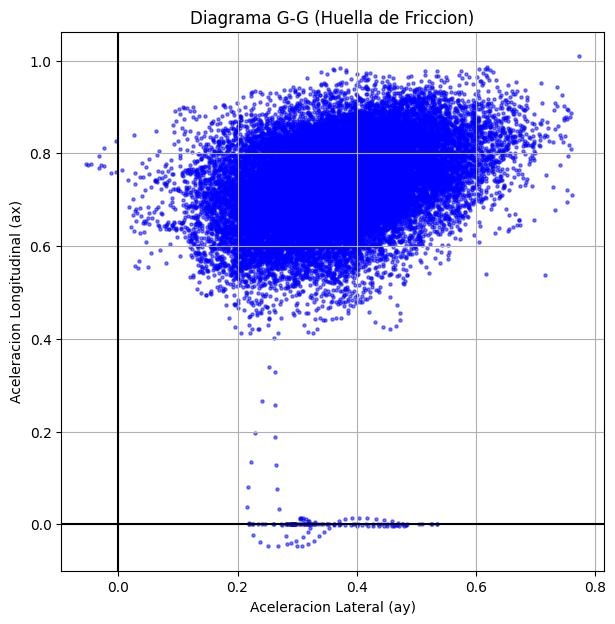

In [ ]:
plt.figure(figsize=(7, 7))
plt.scatter(datos['accel_y_limpia'], datos['accel_x_limpia'], color='blue', s=5, alpha=0.5)

plt.title("Diagrama G-G (Huella de Friccion)")
plt.xlabel("Aceleracion Lateral (ay)")
plt.ylabel("Aceleracion Longitudinal (ax)")
plt.axhline(0, color='black')
plt.axvline(0, color='black')
plt.grid(True)

plt.show()

In [ ]:
falla_sensor = (datos['accel_x'] == 0)
falla_sensor_sostenida = falla_sensor.rolling(10).sum() == 10
tiempo_falla_sensor = datos[falla_sensor_sostenida]

if not tiempo_falla_sensor.empty:
    inicio = tiempo_falla_sensor['Timestamp'].iloc[0]
    fin = tiempo_falla_sensor['Timestamp'].iloc[-1]
    print(f"Falla de sensor detectada desde {inicio}s hasta {fin}s")

falla_plausibilidad = (datos['brake_pressure'] > 5) & (datos['throttle'] > 10)
falla_plaus_sostenida = falla_plausibilidad.rolling(10).sum() == 10
tiempo_plaus = datos[falla_plaus_sostenida]

if not tiempo_plaus.empty:
    inicio_p = tiempo_plaus['Timestamp'].iloc[0]
    print(f"Evento de plausibilidad detectado a los {inicio_p} segundos")

Falla de sensor detectada desde 146.06s hasta 147.46s
Evento de plausibilidad detectado a los 0.09 segundos


In [ ]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

fig = make_subplots(
    rows=2, cols=1,
    shared_xaxes=True,
    subplot_titles=('Aceleraciones Filtradas y Caída de Sensor (IMU)', 'Plausibilidad de Pedales (Freno + Acelerador)')
)

fig.add_trace(go.Scatter(x=datos['Timestamp'], y=datos['accel_x_limpia'], name='Accel X (Filtrada)', line=dict(color='blue')), row=1, col=1)
fig.add_trace(go.Scatter(x=datos['Timestamp'], y=datos['accel_y_limpia'], name='Accel Y (Filtrada)', line=dict(color='cyan')), row=1, col=1)

fig.add_trace(go.Scatter(x=datos['Timestamp'], y=datos['throttle'], name='Acelerador (%)', line=dict(color='green')), row=2, col=1)
fig.add_trace(go.Scatter(x=datos['Timestamp'], y=datos['brake_pressure'], name='Freno (Bar)', line=dict(color='red')), row=2, col=1)

fig.add_vrect(
    x0=0.09, x1=datos['Timestamp'].iloc[-1],
    fillcolor="red", opacity=0.15, line_width=0,
    row=2, col=1,
    annotation_text="⚠️ ALERTA: Plausibilidad Activa (Freno + Acelerador)",
    annotation_position="top left"
)

fig.update_layout(
    title_text="Dashboard Interactivo de Telemetría FSAE",
    height=600,
    hovermode="x unified"
)

fig.show()

#  REPORTE TÉCNICO DE TELEMETRÍA Y DIAGNÓSTICO

## 1.Acondicionamiento de Señal
Para el desarrollo de este pipeline me apoyé en documentación técnica, tutoriales y herramientas de inteligencia artificial para estructurar la lógica en Python, logrando procesar los datos de manera limpia. Se implementó un filtro pasa-bajas Butterworth de 4.º orden a 5 Hz usando filtfilt (fase cero) para eliminar la resonancia del chasis a 100 Hz. El valor crudo de fuerza G es engañoso 2.96G debido a picos de vibración; la magnitud real filtrada resulta en 1.27G.

## 2.Diagrama G-G
En la gráfica se observan valores atípicos fuera del gráfico, así como una ligera asimetría hacia aceleraciones longitudinales y laterales negativas. Esto evidencia:
* Un desbalance físico en el set-up del vehículo (distribución de peso o rigidez de suspensión).
* Ruido remanente o falta de calibración en el cero del sensor inercial (IMU).

## 3.Detección de Anomalías y Seguridad
* Caída de IMU: Se detectó una caída repentina a cero en las lecturas de aceleración en el intervalo intermedio del registro 186.1s a 187.3s, indicando una desconexión o falla momentánea del sensor.
* Violación de Plausibilidad (Freno + Acelerador): En la gráfica inferior se aprecia que la condición de plausibilidad está activa de forma prácticamente continua durante todo el recorrido. El acelerador y la presión de freno se aplican en simultáneo constantemente por encima de los 100ms, disparando el evento de seguridad de forma sostenida.

## 4.Acciones Recomendadas
1. Revisión del Pedalier: Ajustar mecánicamente o mediante software la zona muerta de los pedales para evitar que el sensor de freno marque presión mientras se acelera.
2. Revisión Eléctrica: Verificar el arnés y fijación de la IMU para solucionar la caída de señal detectada.